In [1]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

torch.manual_seed(0)

device: cpu


Génération de données synthétiques

In [26]:
sigma_base = 2
eps_mean= 3
data='gaussian'  # 'gaussian' or 'mixture'
n_samples = 30000



# Mixture parameters for X_0
mixture_weights = torch.tensor([0.5, 0.5], device=device)
mixture_means = torch.tensor([1, 5.0], device=device)
mixture_stds = torch.tensor([0.4, 0.4], device=device)


def sample_x0_mixture(batch_size):
    """
    Sample hidden clean latent X_0 from a 1D Gaussian mixture.

        X_0 ~ sum_k pi_k N(mu_k, std_k^2)
    """

    # sample component indices
    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True
    )

   
    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)

    # sample from selected Gaussian component
    x0 = means + stds * torch.randn(batch_size, 1, device=device)

    return x0

def sample_x0(batch_size, mu_x=3.0, var_x=0.4):
    std_x = torch.sqrt(torch.tensor(var_x, device=device))
    x0 = mu_x + std_x * torch.randn(batch_size, 1, device=device)
    return x0


def sample_z0_from_x0(x0):
    """
    Observation model:
    
        Z_0 = X_0 + sigma * eps_0
    """
    eps0 = eps_mean +  torch.randn_like(x0)
    z0 = x0 + sigma_base *eps0
    return z0


def sample_joint_data(batch_size, data):
    """
    Return both hidden X_0 and observed Z_0.
    """
    if data == 'mixture':
        x0 = sample_x0_mixture(batch_size)
    else:
        x0 = sample_x0(batch_size, mu_x=3.0, var_x=0.4)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def sample_data(batch_size, data=data):
    """
    The DDPM only observes Z_0.
    """
    _, z0 = sample_joint_data(batch_size, data=data)
    return z0

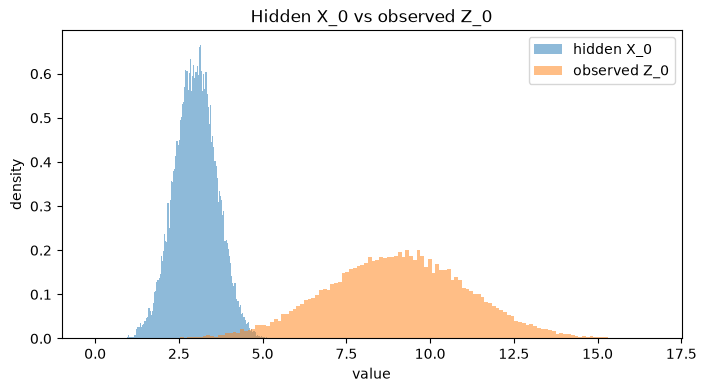

In [27]:
x0, z0 = sample_joint_data(n_samples, data=data)

x0_np = x0.detach().cpu().numpy()
z0_np = z0.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(x0_np, bins=150, density=True, alpha=0.5, label="hidden X_0")
plt.hist(z0_np, bins=150, density=True, alpha=0.5, label="observed Z_0")
plt.title("Hidden X_0 vs observed Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

Hyperparamètre et noise schedule

In [35]:
T = 1000

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T, device=device) # Schedule linéaire pour les betas
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def sigma2_at_index(t_index):
    """
    Return sigma_t^2 = sigma_base^2 / 2^t for Python index t.
    t_index shape: (batch_size,)
    """
    return sigma_base**2 * torch.exp(-math.log(2.0) * t_index.float())


def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_at_index(t)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))

def extract(v, t, x_shape):
    """
    Extract v[t] for each element of the batch, then reshape for broadcasting.

    v: tensor of shape (T,)
       Example: betas, alphas, alpha_bars

    t: tensor of shape (batch_size,)
       Time index for each sample in the batch.

    x_shape: shape of the variable we want to multiply with.
       Example: z.shape = (batch_size, 1)

    Returns:
       tensor of shape (batch_size, 1, ..., 1)
    """
    out = v.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Forward

In [36]:
def q_sample(z0, t, eps=None):
    """
    Sample z_t from q(z_t | z_0).
    """
    if eps is None:
        eps = torch.randn_like(z0)

    alpha_bar_t = extract(alpha_bars, t, z0.shape)

    zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return zt, eps

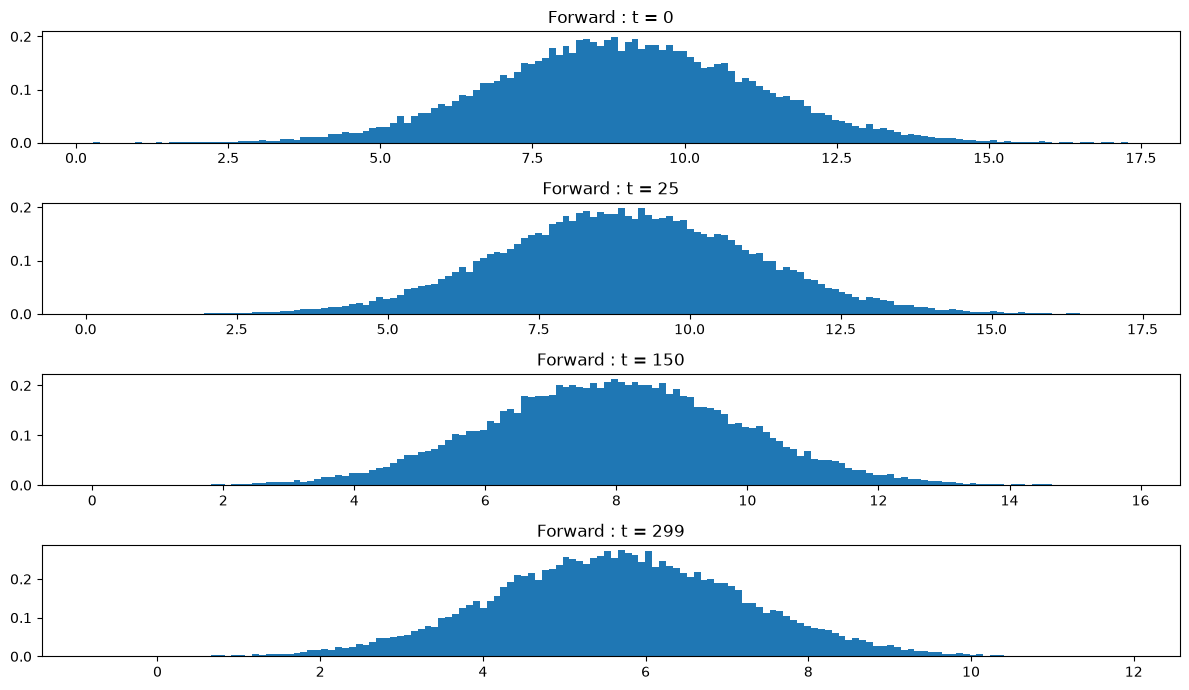

In [37]:
z0 = sample_data(30000, data=data)

times_to_plot = [0, 25, 150, 299]

plt.figure(figsize=(12, 7))

for i, tt in enumerate(times_to_plot):
    t = torch.full((z0.shape[0],), tt, device=device, dtype=torch.long)
    zt, _ = q_sample(z0, t)
    zt_np = zt.detach().cpu().numpy()

    plt.subplot(len(times_to_plot), 1, i + 1)
    plt.hist(zt_np, bins=150, density=True)
    plt.title(f"Forward : t = {tt}")

plt.tight_layout()
plt.show()

Entrainement pour prédire le score

In [38]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        """
        t: shape (batch_size,)
        returns: shape (batch_size, dim)
        """
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=t.device) / (half_dim - 1)
        )
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ScoreModel(nn.Module):
    def __init__(self, time_dim=64, hidden_dim=128):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.net = nn.Sequential(
            nn.Linear(1 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, zt, t):
        t_emb = self.time_embedding(t)
        x = torch.cat([zt, t_emb], dim=-1)
        return self.net(x)


model = ScoreModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [39]:

batch_size = 1024
num_steps = 8000

loss_history = []

for step in range(1, num_steps + 1):
    z0 = sample_data(batch_size)

    t = torch.randint(0, T, (batch_size,), device=device).long()

    eps = torch.randn_like(z0)
    zt, eps = q_sample(z0, t, eps)

    alpha_bar_t = extract(alpha_bars, t, z0.shape)

    target_score = -eps / torch.sqrt(1.0 - alpha_bar_t)

    score_pred = model(zt, t)

    weight = 1.0 - alpha_bar_t

    loss = (weight * (score_pred - target_score) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 500 == 0:
        print(f"step {step:05d} | loss = {loss.item():.6f}")

step 00500 | loss = 0.435213
step 01000 | loss = 0.364958
step 01500 | loss = 0.429428
step 02000 | loss = 0.436214
step 02500 | loss = 0.378543
step 03000 | loss = 0.385334
step 03500 | loss = 0.445922
step 04000 | loss = 0.424560
step 04500 | loss = 0.420292
step 05000 | loss = 0.470794
step 05500 | loss = 0.444761
step 06000 | loss = 0.396287
step 06500 | loss = 0.435518
step 07000 | loss = 0.438195
step 07500 | loss = 0.384237
step 08000 | loss = 0.373489


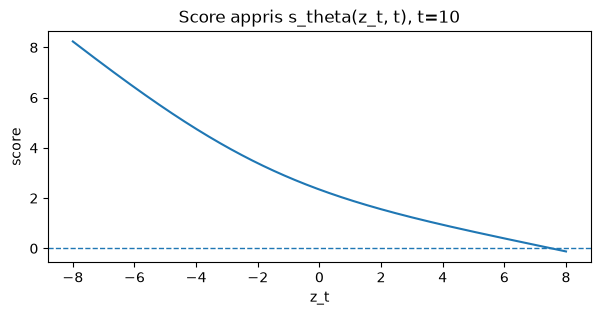

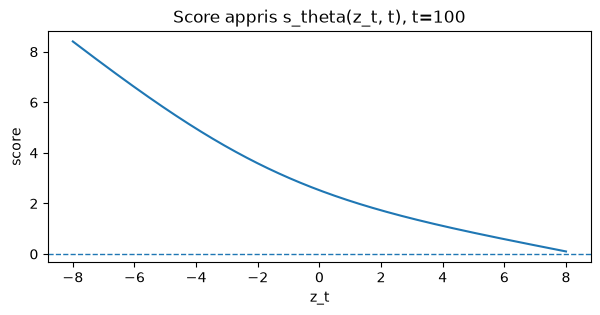

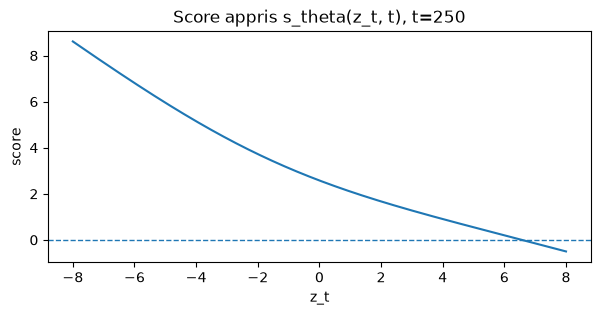

In [40]:
@torch.no_grad()
def plot_score_at_time(time_step):
    grid = torch.linspace(-8, 8, 600, device=device)[:, None]
    t = torch.full((grid.shape[0],), time_step, device=device, dtype=torch.long)

    score = model(grid, t)

    plt.figure(figsize=(7, 3))
    plt.plot(grid.cpu().numpy(), score.cpu().numpy())
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Score appris s_theta(z_t, t), t={time_step}")
    plt.xlabel("z_t")
    plt.ylabel("score")
    plt.show()

plot_score_at_time(10)
plot_score_at_time(100)
plot_score_at_time(250)

Sampling

In [41]:


@torch.no_grad()
def p_sample_hidden_x_score(model, zt, t):
    """
    One adapted reverse step.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(alpha_bars, t, zt.shape)

    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2

    #Biais
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean
    # Score of the observed distribution f_t^Z
    score = model(zt, t)

    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt - bias_t + delta_t * score) / torch.sqrt(alpha_t)




    

    noise_z = torch.randn_like(zt)

    # As in DDPM, no Z-noise at the last step
    nonzero_mask = (t != 0).float().reshape(-1, 1)

    z_prev = x_prev_hat +sigma_prev * eps_mean+ nonzero_mask * torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev_hat

In [42]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm(model, n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
    model.eval()

    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev,  x_prev_hat,= p_sample_hidden_x_score(model, zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),

                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),

                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev_hat.detach().cpu()

    return x0_hat, z0_hat, trajectory

No noise

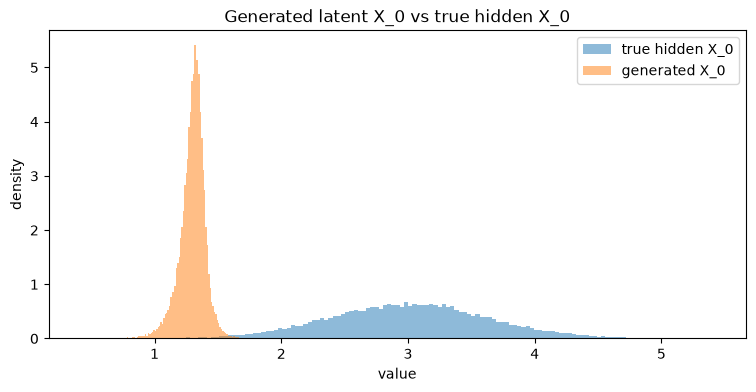

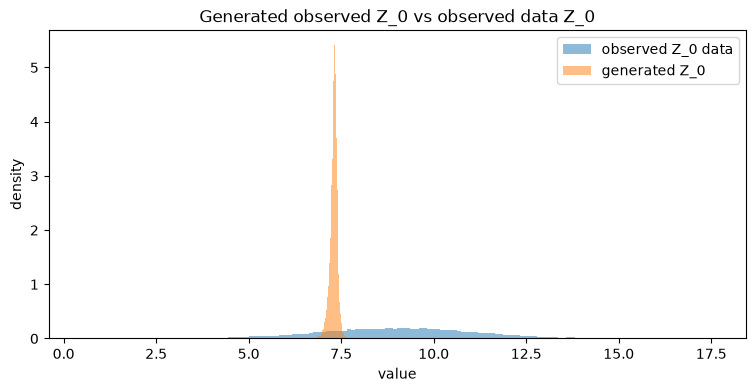

In [43]:

x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm(model, n_samples=30000)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="observed Z_0 data")
plt.hist(z0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated Z_0")
plt.title("Generated observed Z_0 vs observed data Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

